---
date: "2026-07-11"
date-modified: last-modified
format:
  html:
    toc: true
---
<!-- CELL BREAK -->

# Measure Spaces

## 1\. Motivation for Measure Theory

The historical drive toward measure theory and the Lebesgue integral stemmed from the limitations of the Riemann integral. Key issues with the Riemann framework include:

1.  **Limits of Functions:** The point-wise limit of a sequence of continuous functions is not necessarily continuous. More problematically, the limit of a sequence of Riemann-integrable functions $f_n \to f$ is not necessarily Riemann-integrable. We need a more robust space of functions that is "closed" under taking limits.
2.  **Geometric Pathologies:** Can we define a universal "measure" (generalizing length, area, and volume) on *all* subsets of $\mathbb{R}^n$ that behaves exactly like standard Euclidean volume? The answer is no, famously demonstrated by the [Banach-Tarski paradox](https://en.wikipedia.org/wiki/Banach%E2%80%93Tarski_paradox). This paradox shows that it is possible to take a solid 3D sphere, partition it into a finite number of pieces ($E_1, \dots, E_n$), and reassemble them using only rigid rotations and translations to form *two* identical copies of the original sphere!

To resolve this, we must restrict the sets we are willing to measure to a [sigma-algebra](sigma-algebra.ipynb) and define a rigorous, abstract concept of a measure.

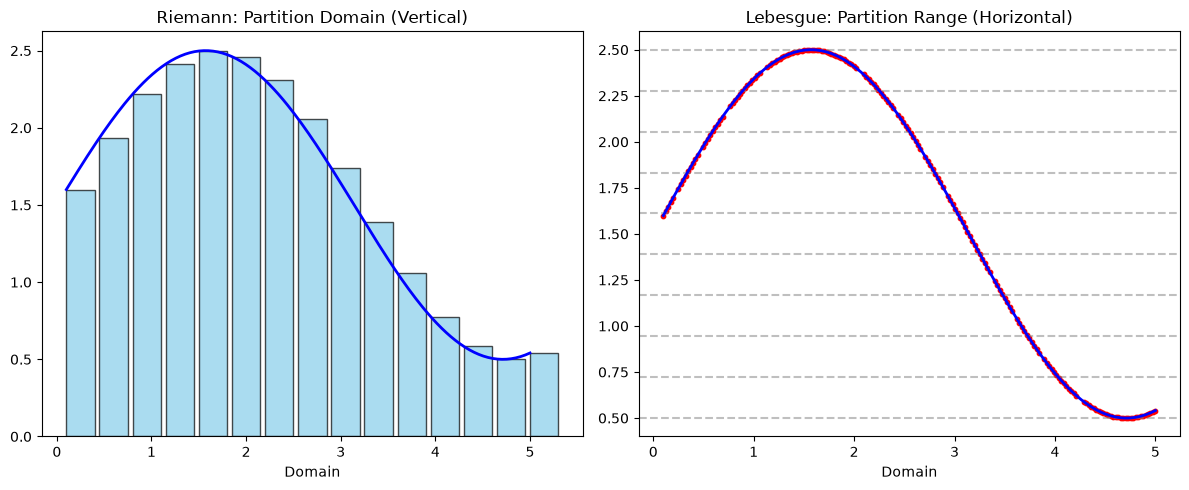

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Visualization of Riemann (Vertical) vs Lebesgue (Horizontal) intuition
x = np.linspace(0.1, 5, 200)
y = np.sin(x) + 1.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Riemann: Partition the domain (x-axis)
x_bars = np.linspace(0.1, 5, 15)
y_bars = np.sin(x_bars) + 1.5
ax1.bar(x_bars, y_bars, width=0.3, align='edge', color='skyblue', edgecolor='black', alpha=0.7)
ax1.plot(x, y, color='blue', linewidth=2)
ax1.set_title("Riemann: Partition Domain (Vertical)")
ax1.set_xlabel("Domain")

# Lebesgue: Partition the range (y-axis)
y_levels = np.linspace(0.5, 2.5, 10)
for level in y_levels:
    ax2.axhline(level, color='gray', linestyle='--', alpha=0.5)
    # Highlight points on curve close to the level
    mask = np.abs(y - level) < 0.1
    ax2.scatter(x[mask], y[mask], color='red', s=10)
    
ax2.plot(x, y, color='blue', linewidth=2)
ax2.set_title("Lebesgue: Partition Range (Horizontal)")
ax2.set_xlabel("Domain")

plt.tight_layout()
plt.show()



## 2. Measurable Spaces and Measures

We build a measure space in two structural steps. First, we pair a set with a [$\sigma$-algebra](sigma-algebra.ipynb). Second, we assign a measure to that structure.

**Definition:** A **measurable space** is a pair $(X, \mathcal{M})$ consisting of a set $X$ and a $\sigma$-algebra $\mathcal{M}$ of subsets of $X$. A subset $E \subseteq X$ is called **measurable** (with respect to $\mathcal{M}$) if $E \in \mathcal{M}$.

**Definition:** Let $(X, \mathcal{M})$ be a measurable space. A **measure** $\mu$ is an extended real-valued set function $\mu : \mathcal{M} \rightarrow [0, \infty]$ that satisfies the following properties:

1. **Non-negativity:** $\mu(E) \ge 0$ for all $E \in \mathcal{M}$.
2. **Measure of Empty Set:** $\mu(\emptyset) = 0$.
3. **Countable Additivity:** For any countable disjoint collection $\{E_k\}_{k=1}^\infty$ of measurable sets, the measure of their union is the sum of their measures:
$$\mu\left( \bigcup_{k=1}^\infty E_k \right) = \sum_{k=1}^\infty \mu(E_k)$$



A **measure space** is defined as the triplet $(X, \mathcal{M}, \mu)$.

::: {.callout-note}

## Note on Subspaces

If $(X, \mathcal{M}, \mu)$ is a measure space and we take a measurable subset $X_0 \in \mathcal{M}$, we can construct a new measure space $(X_0, \mathcal{M}_0, \mu_0)$ where $\mathcal{M}_0$ contains all sets in $\mathcal{M}$ that are subsets of $X_0$, and $\mu_0$ is simply the restriction of $\mu$.
:::

## 3. Common Examples of Measures

Several standard measures populate analysis and probability:

1. **Lebesgue Measure Space** $(\mathbb{R}, \mathcal{L}, m)$: $m$ is the standard Lebesgue measure extending the notion of "length" of intervals.
2. **Borel Measure Space** $(\mathbb{R}, \mathcal{B}, m)$: The same Lebesgue measure, but strictly restricted to the smaller [Borel sigma-algebra]().
3. **Counting Measure:** Defined on the measurable space $(X, 2^X)$. For any finite set $E$, $\mu(E) = |E|$ (the number of elements). If $E$ is infinite, $\mu(E) = \infty$.
4. **Dirac Measure:** For a specific point $x_0 \in X$, the Dirac measure $\delta_{x_0}$ assigns a measure of $1$ if $x_0 \in E$ and $0$ if $x_0 \notin E$. This forms the Dirac measure space $(X, \mathcal{M}, \delta_{x_0})$.
5. **Countable/Co-countable Measure:** Let $X$ be an uncountable set, and let $\mathcal{M}$ be the collection of all subsets that are either countable or whose complement is countable (co-countable). We define $\mu(E) = 0$ if $E$ is countable, and $\mu(E) = 1$ if $E^c$ is countable.

## 4. Fundamental Properties of Measures

A standard measure automatically enjoys several highly intuitive arithmetic properties.

**Proposition 1:** Let $(X, \mathcal{M}, \mu)$ be a measure space. The measure $\mu$ exhibits finite additivity, monotonicity, and excision.

::: {.callout-tip collapse="false"}

## Proof of Finite Additivity

**Statement:** For any finite disjoint collection $\{E_k\}_{k=1}^n$ of measurable sets, $\mu(\bigcup_{k=1}^n E_k) = \sum_{k=1}^n \mu(E_k)$.

**Proof:**
We know by definition that $\mu$ is countably additive. To prove finite additivity from countable additivity, we simply "pad" our finite sequence of sets with empty sets.
Let $E_{n+1} = \emptyset, E_{n+2} = \emptyset, \dots$
Because the empty set is disjoint from every set, the infinite sequence $\{E_k\}_{k=1}^\infty$ is still a disjoint collection.
Using countable additivity:

$$\begin{aligned}
\mu\left( \bigcup_{k=1}^n E_k \right) &= \mu\left( \bigcup_{k=1}^\infty E_k \right) \\
&= \sum_{k=1}^\infty \mu(E_k) \\
&= \sum_{k=1}^n \mu(E_k) + \sum_{k=n+1}^\infty \mu(\emptyset) \\
&= \sum_{k=1}^n \mu(E_k) + 0 \\
&= \sum_{k=1}^n \mu(E_k)
\end{aligned}$$

$\blacksquare$
:::

::: {.callout-tip collapse="false"}

## Proof of Monotonicity

**Statement:** If $A$ and $B$ are measurable sets and $A \subseteq B$, then $\mu(A) \le \mu(B)$.

**Proof:**
Since $A \subseteq B$, we can decompose $B$ into two disjoint measurable sets: $A$ and the relative complement $B \setminus A$.

$$B = A \cup (B \setminus A)$$

Because these sets are disjoint, we apply finite additivity:

$$\mu(B) = \mu(A) + \mu(B \setminus A)$$

By definition, measures are non-negative, so $\mu(B \setminus A) \ge 0$. Therefore:

$$\mu(B) \ge \mu(A)$$

$\blacksquare$
:::

::: {.callout-tip collapse="false"}

## Proof of Excision

**Statement:** If $A \subseteq B$ and $\mu(A) < \infty$, then $\mu(B \setminus A) = \mu(B) - \mu(A)$. Consequently, if $\mu(A) = 0$, then $\mu(B \setminus A) = \mu(B)$.

**Proof:**
From the proof of monotonicity, we established the decomposition:

$$\mu(B) = \mu(A) + \mu(B \setminus A)$$

Because we are explicitly given that $\mu(A) < \infty$, we are safely allowed to subtract $\mu(A)$ from both sides of the equation without running into indeterminate arithmetic (like $\infty - \infty$). Subtracting $\mu(A)$ yields:

$$\mu(B \setminus A) = \mu(B) - \mu(A)$$

If $\mu(A) = 0$, then clearly $\mu(B \setminus A) = \mu(B) - 0 = \mu(B)$. $\blacksquare$
:::

::: {.callout-warning}

## Warning on Excision

The condition that $\mu(A) < \infty$ in the Excision property is absolutely critical. If $\mu(A) = \infty$ and $\mu(B) = \infty$, the subtraction $\infty - \infty$ is mathematically undefined in measure theory. You cannot perform excision on infinite measure sets.
:::


## 4\. The Countable / Co-countable Sigma-Algebra

An important example of a non-trivial $\sigma$-algebra on an arbitrary (usually uncountable) set is the countable/co-countable $\sigma$-algebra. 

**Proposition:** Let $X$ be an arbitrary set. Let $\mathcal{M}$ be the collection of all subsets $E \subseteq X$ such that either $E$ is countable or its complement $E^c$ is countable. Then $\mathcal{M}$ is a [sigma-algebra]() on $X$.

::: {.callout-tip collapse="false"}
## Proof of the Countable/Co-countable $\sigma$-algebra
To prove that $\mathcal{M}$ is a $\sigma$-algebra, we must verify the three defining properties:

**Step 1:** The empty set $\emptyset$ has zero elements, meaning it is finite and therefore countable. Thus, $\emptyset \in \mathcal{M}$.

**Step 2 (Closure under complementation):** 
Let $E \in \mathcal{M}$. By definition, this means either $E$ is countable or $E^c$ is countable. 

*   If $E$ is countable, then the complement of $E^c$ (which is $(E^c)^c = E$) is countable, meaning $E^c \in \mathcal{M}$. 
*   If $E^c$ is countable, then by definition $E^c \in \mathcal{M}$. 

In either scenario, $E^c \in \mathcal{M}$.

**Step 3 (Closure under countable unions):** 
Let $\{E_1, E_2, \dots \}$ be a countable sequence of sets in $\mathcal{M}$. We need to show that their union $\bigcup_{i=1}^\infty E_i$ is also in $\mathcal{M}$. There are two possible cases to consider:

*   **Case 1:** Every set $E_i$ in the sequence is countable. Because a countable union of countable sets is itself countable, $\bigcup_{i=1}^\infty E_i$ is countable. Therefore, it belongs to $\mathcal{M}$.
*   **Case 2:** At least one set in the sequence, say $E_k$, is co-countable (meaning $E_k^c$ is countable). We want to show that the union is co-countable. Using [De Morgan's laws](), we look at the complement of the union:
    $$
    \left( \bigcup_{i=1}^\infty E_i \right)^c = \bigcap_{i=1}^\infty E_i^c
    $$
    Since the intersection of sets is a subset of any individual set in the intersection, we have:
    $$
    \bigcap_{i=1}^\infty E_i^c \subseteq E_k^c
    $$
    We assumed $E_k^c$ is countable, and any subset of a countable set must also be countable. Therefore, the complement of the union, $\left( \bigcup_{i=1}^\infty E_i \right)^c$, is countable. This implies that the union $\bigcup_{i=1}^\infty E_i$ is co-countable, and thus belongs to $\mathcal{M}$.

Since $\mathcal{M}$ contains the empty set and is closed under both complements and countable unions, it is a valid $\sigma$-algebra. $\blacksquare$
:::


## 5\. Example: Extending a Measure from Singletons

Suppose we have an arbitrary set $X$ and a non-negative function $\mu$ defined only on the singleton subsets of $X$. We want to know if we can extend this $\mu$ to a full measure on the entire space $X$.

To do this, we consider $\mathcal{M}$, the sigma-algebra generated by the singleton sets. As established earlier, this generated $\sigma$-algebra is precisely the collection of all countable or co-countable subsets of $X$. For any set $E \in \mathcal{M}$, we can define the extended measure $\mu(E)$ by considering two distinct cases:

**Case 1: $E$ is countable**
If $E = \{x_1, x_2, \dots\}$ is a countable set, we define its measure by simply summing the measures of its individual elements:
$$
\mu(E) = \sum_{i=1}^\infty \mu(\{x_i\})
$$

**Case 2: $E$ is uncountable**
If $E$ is an uncountable set (which implies its complement must be countable for it to be in $\mathcal{M}$), we must look at the specific elements within $E$ that have a strictly positive measure.

*   If $E$ contains *uncountably* many elements with a positive measure, we define $\mu(E) = \infty$.
*   If $E$ contains *at most countably* many elements with a positive measure, we define the measure as the sum of those positive values:
    $$
    \mu(E) = \sum_{x_i \in E, \mu(\{x_i\}) > 0} \mu(\{x_i\})
    $$

::: {.callout-tip collapse="false"}
## Solution: Proof that the Extension is a Measure
**Exercise Statement:** Prove that the extended function $\mu$ described above is a valid measure on $\mathcal{M}$.

**Proof:**
To verify that $\mu$ is a measure, we must check the three fundamental properties:

**1. Non-negativity:** By definition, the measure of a singleton is non-negative, and $\mu(E)$ is defined either as a sum of non-negative terms or as $\infty$. Thus, $\mu(E) \ge 0$ for all $E \in \mathcal{M}$.

**2. Measure of Empty Set:** The empty set $\emptyset$ is finite and therefore falls under Case 1 (it is countable). Its measure is the empty sum, which is mathematically defined as $0$.

**3. Countable Additivity:** Let $\{E_k\}_{k=1}^\infty$ be a countable disjoint collection of sets in $\mathcal{M}$, and let $E = \bigcup_{k=1}^\infty E_k$. We must show $\mu(E) = \sum_{k=1}^\infty \mu(E_k)$.

*   *Sub-case A (All $E_k$ are countable):* If all $E_k$ are countable, their union $E$ is also a countable set. By definition, $\mu(E)$ is the sum of $\mu(\{x\})$ for all $x \in E$. Since the sets are mutually disjoint, summing over all elements of the union is identical to summing over the elements of each set individually and then adding those sums together. Thus, additivity holds.
*   *Sub-case B (One $E_k$ is uncountable):* Because the sets are in $\mathcal{M}$ and are mutually disjoint, *at most one* set in the collection, say $E_j$, can be uncountable. (If there were two, both would be co-countable, meaning their complements would be countable. The intersection of two co-countable sets is uncountable, which would violate the disjointness condition). 
    Since $E_j$ is uncountable, the union $E$ is also uncountable.
     
    *   If uncountably many elements in $E$ have positive measure, then both $\mu(E) = \infty$ and the sum $\sum \mu(E_k) = \infty$ (because $\mu(E_j)$ alone will be $\infty$). 
    *   If at most countably many elements in $E$ have positive measure, then any sum over $E$ strictly evaluates the non-zero terms. Since all non-zero terms are countable, they can be unconditionally rearranged into the sums over the individual $E_k$ sets. 
    
Therefore, $\mu$ is countably additive. $\blacksquare$
:::



## 5\. Countable Monotonicity (Subadditivity)

Another critical property of measures is **countable monotonicity**, often referred to as **countable subadditivity**. It states that the measure of a set covered by a countable union of measurable sets is bounded by the sum of their individual measures, even if those sets overlap.

**Proposition (Countable Monotonicity):** Let $(X, \mathcal{M}, \mu)$ be a measure space. For any countable collection of measurable sets $\{E_k\}_{k=1}^\infty$ that covers a measurable set $E$ (meaning $E \subseteq \bigcup_{k=1}^\infty E_k$), we have:
$$\mu(E) \le \sum_{k=1}^\infty \mu(E_k)$$

::: {.callout-note}
## Intuition: The Disjointification Trick
When sets in the collection overlap, summing their measures double-counts (or infinitely counts) the intersecting regions. To rigorously prove the bound, we construct a new sequence of sets, $\{G_k\}$, by "shaving off" the overlapping parts of each successive $E_k$. This guarantees the new sets are mutually disjoint while covering the exact same total area.
:::

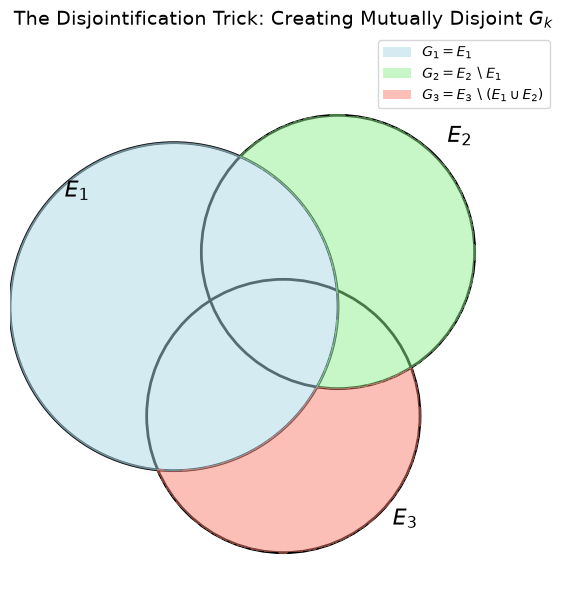

In [2]:


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.path import Path
from matplotlib.patches import PathPatch

fig, ax = plt.subplots(figsize=(8, 6))

# Define three overlapping sets (circles)
circle1 = Circle((0.3, 0.5), 0.3, fill=False, edgecolor='black', linewidth=2)
circle2 = Circle((0.6, 0.6), 0.25, fill=False, edgecolor='black', linewidth=2)
circle3 = Circle((0.5, 0.3), 0.25, fill=False, edgecolor='black', linewidth=2)

ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)

# Add text labels
ax.text(0.1, 0.7, '$E_1$', fontsize=16)
ax.text(0.8, 0.8, '$E_2$', fontsize=16)
ax.text(0.7, 0.1, '$E_3$', fontsize=16)

# Highlight G1 (which is just E1)
circle1_fill = Circle((0.3, 0.5), 0.3, fill=True, color='lightblue', alpha=0.5, label='$G_1 = E_1$')
ax.add_patch(circle1_fill)

# Highlight G2 (E2 \ E1) by clipping
# We create a clipping path that is E2 but excludes E1
x = np.linspace(0, 1, 400)
y = np.linspace(0, 1, 400)
X, Y = np.meshgrid(x, y)
# Distances to centers
d1 = np.sqrt((X - 0.3)**2 + (Y - 0.5)**2)
d2 = np.sqrt((X - 0.6)**2 + (Y - 0.6)**2)
d3 = np.sqrt((X - 0.5)**2 + (Y - 0.3)**2)

# Mask for G2
mask_G2 = (d2 <= 0.25) & (d1 > 0.3)
ax.contourf(X, Y, mask_G2, levels=[0.5, 1.5], colors=['lightgreen'], alpha=0.5)

# Mask for G3 (E3 \ (E1 U E2))
mask_G3 = (d3 <= 0.25) & (d1 > 0.3) & (d2 > 0.25)
ax.contourf(X, Y, mask_G3, levels=[0.5, 1.5], colors=['salmon'], alpha=0.5)

# Setup plot limits and aesthetics
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("The Disjointification Trick: Creating Mutually Disjoint $G_k$", fontsize=14)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightblue', alpha=0.5, label='$G_1 = E_1$'),
    Patch(facecolor='lightgreen', alpha=0.5, label='$G_2 = E_2 \\setminus E_1$'),
    Patch(facecolor='salmon', alpha=0.5, label='$G_3 = E_3 \\setminus (E_1 \\cup E_2)$')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()



::: {.callout-tip collapse="false"}

## Proof of Countable Monotonicity

**Step 1: Construct mutually disjoint sets**
Let $\{E_k\}_{k=1}^\infty$ be our countable collection of measurable sets. We construct a new collection of sets $\{G_k\}_{k=1}^\infty$ iteratively:

$$\begin{aligned}
G_1 &= E_1 \\
G_2 &= E_2 \setminus E_1 \\
G_3 &= E_3 \setminus (E_1 \cup E_2) \\
&\vdots \\
G_k &= E_k \setminus \left( \bigcup_{i=1}^{k-1} E_i \right) \quad \text{for all } k \ge 2.
\end{aligned}$$

**Step 2: Establish properties of $G_k$**
By construction, the sequence $\{G_k\}_{k=1}^\infty$ has three vital properties:

1. **Disjointness:** $G_i \cap G_j = \emptyset$ for all $i \neq j$.
2. **Subset relation:** $G_k \subseteq E_k$ for all $k$. By the monotonicity of measures, this implies $\mu(G_k) \le \mu(E_k)$.
3. **Preservation of union:** The total union remains unchanged. That is, $\bigcup_{k=1}^\infty G_k = \bigcup_{k=1}^\infty E_k$.

**Step 3: Apply measure properties**
We are given that $E \subseteq \bigcup_{k=1}^\infty E_k$. Using the fact that the union of $E_k$ is exactly equal to the union of $G_k$, we have:

$$E \subseteq \bigcup_{k=1}^\infty G_k$$

By the monotonicity property of measures established earlier:

$$\mu(E) \le \mu\left( \bigcup_{k=1}^\infty G_k \right)$$

Because the sets $\{G_k\}_{k=1}^\infty$ are mutually disjoint, we can apply the countable additivity property of measures:

$$\mu\left( \bigcup_{k=1}^\infty G_k \right) = \sum_{k=1}^\infty \mu(G_k)$$

Finally, since $G_k \subseteq E_k$ implies $\mu(G_k) \le \mu(E_k)$ for each $k$, we substitute this bound into our sum:

$$\sum_{k=1}^\infty \mu(G_k) \le \sum_{k=1}^\infty \mu(E_k)$$

Chaining these inequalities together yields the final result:

$$\mu(E) \le \sum_{k=1}^\infty \mu(E_k)$$

$\blacksquare$
:::